# Group 3: Moisture Prediction from NIR Spectra

**Spectral regression with a 1D CNN**  
Synthetic teaching dataset. Session 9: Group Deep Learning Challenge.

<a href="https://colab.research.google.com/github/khairuladib94/dl-food-research/blob/main/session-9/notebooks/03_group3_nir_moisture_1dcnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

> **Colab workflow:** Save a copy in Drive, then choose Runtime > Run all. The required teaching dataset downloads automatically; Google Drive is not mounted.



## How to work
1. Run the baseline. 2. Change one main factor in Experiment 1. 3. Change one main factor in Experiment 2. 4. Record evidence for your five-slide presentation.

In [1]:
from pathlib import Path
import os, time, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score, recall_score, precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
keras.utils.set_random_seed(SEED)
# Portable workshop data setup: local Jupyter first, Colab fallback.
DATA_FILE = 'group3_nir_moisture.npz'
LOCAL_DATA_DIR = Path('../data')
if (LOCAL_DATA_DIR / DATA_FILE).exists():
    DATA_DIR = LOCAL_DATA_DIR
    IN_COLAB = False
else:
    from urllib.request import urlretrieve
    try:
        import google.colab  # type: ignore  # noqa: F401
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False
    DATA_DIR = Path('/content/dl-food-research-data') if IN_COLAB else Path.cwd() / '.workshop-data'
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    target = DATA_DIR / DATA_FILE
    if not target.exists():
        url = 'https://raw.githubusercontent.com/khairuladib94/dl-food-research/main' + '/session-9/data/' + DATA_FILE
        print(f'Downloading {DATA_FILE} ...')
        urlretrieve(url, target)
    print(f'Dataset ready: {target}')
FIG_DIR = Path('/content/dl-food-research-figures') if IN_COLAB else Path('../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('TensorFlow:', tf.__version__, '| Keras:', keras.__version__)


TensorFlow: 2.21.0 | Keras: 3.15.0


## 1. Load and explore spectra

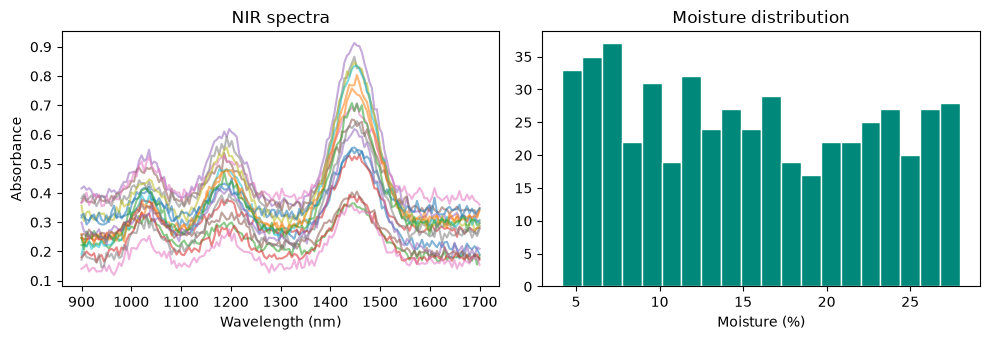

In [2]:
d=np.load(DATA_DIR/'group3_nir_moisture.npz')
X,y,w=d['spectra'],d['moisture'],d['wavelength']
fig,ax=plt.subplots(1,2,figsize=(10,3.5))
for i in np.linspace(0,len(X)-1,18,dtype=int): ax[0].plot(w,X[i],alpha=.55)
ax[0].set(title='NIR spectra',xlabel='Wavelength (nm)',ylabel='Absorbance')
ax[1].hist(y,bins=20,color='#00897b',edgecolor='white'); ax[1].set(title='Moisture distribution',xlabel='Moisture (%)')
plt.tight_layout(); plt.savefig(FIG_DIR/'group3_eda.png',dpi=150); plt.show()

In [3]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,random_state=SEED)
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,test_size=.20,random_state=SEED)
def snv(a):
    return (a-a.mean(axis=1,keepdims=True))/(a.std(axis=1,keepdims=True)+1e-8)


## 2. Baseline and two controlled experiments

In [4]:
def build_1d(input_len,filters=(8,16),kernel=5):
    model=keras.Sequential([keras.layers.Input((input_len,1))])
    for f in filters: model.add(keras.layers.Conv1D(f,kernel,activation='relu',padding='same')); model.add(keras.layers.MaxPooling1D(2))
    model.add(keras.layers.GlobalAveragePooling1D()); model.add(keras.layers.Dense(16,activation='relu')); model.add(keras.layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(.004),loss='mse',metrics=['mae'])
    return model

def run(name, preprocess=False, filters=(8,16), kernel=5, epochs=18):
    keras.utils.set_random_seed(SEED)
    tr,va,te=(snv(X_train),snv(X_val),snv(X_test)) if preprocess else (X_train,X_val,X_test)
    model=build_1d(tr.shape[1],filters,kernel)
    hist=model.fit(tr[...,None],y_train,validation_data=(va[...,None],y_val),epochs=epochs,batch_size=32,verbose=0)
    pred=model.predict(te[...,None],verbose=0).ravel()
    return model,hist,pred,{'run':name,'RMSE':mean_squared_error(y_test,pred)**.5,'R2':r2_score(y_test,pred)}

baseline=run('Baseline: k5, 8 filters',filters=(8,),kernel=5,epochs=7)
exp1=run('Exp 1: k9, 16-32',filters=(16,32),kernel=9)
exp2=run('Exp 2: SNV preprocessing',preprocess=True,filters=(16,32),kernel=7)
results=pd.DataFrame([baseline[3],exp1[3],exp2[3]])
display(results.round(3))

,run,RMSE,R2
0,"Baseline: k5, 8 filters",13.444,-2.442
1,"Exp 1: k9, 16-32",6.391,0.222
2,Exp 2: SNV preprocessing,7.359,-0.031


### YOUR TASK
Compare kernel/filter settings and one defensible spectral preprocessing choice such as SNV.

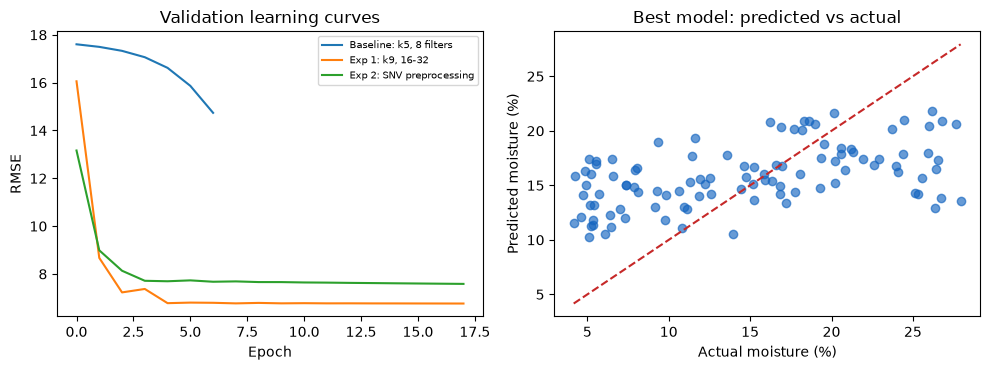

Presentation-ready summary: {'run': 'Exp 1: k9, 16-32', 'RMSE': 6.391407515317379, 'R2': 0.2220504879951477}


In [5]:
best=min([baseline,exp1,exp2],key=lambda r:r[3]['RMSE'])
fig,ax=plt.subplots(1,2,figsize=(10,3.8))
for r in [baseline,exp1,exp2]: ax[0].plot(np.sqrt(r[1].history['val_loss']),label=r[3]['run'])
ax[0].set(title='Validation learning curves',xlabel='Epoch',ylabel='RMSE'); ax[0].legend(fontsize=7)
ax[1].scatter(y_test,best[2],alpha=.65,color='#1565c0'); lim=[y_test.min(),y_test.max()]; ax[1].plot(lim,lim,'--',color='#c62828')
ax[1].set(title='Best model: predicted vs actual',xlabel='Actual moisture (%)',ylabel='Predicted moisture (%)')
plt.tight_layout(); plt.savefig(FIG_DIR/'group3_results.png',dpi=150); plt.show()
print('Presentation-ready summary:',best[3])